In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

class DiamondAnalysis:
    def __init__(self, filename):
        self.filename = filename
        self.data = {}
        self.load_data()
        
        # Initial guesses/Parameters
        self.params = {
            'height': 0.1, 'dist': 5, 'prom': 0.05,
            'L_roi': (None, None), 'R_roi': (None, None)
        }
        self.results = {} # Store fit results here

    def load_data(self):
        """Loads data and handles unit conversion."""
        with h5py.File(self.filename, 'r') as f:
            # Extract raw data
            raw = f['Data']['Data'][:]
            
            # Mapping indices to readable names
            # Adjust these indices if your machine config changes
            IDX_VSD = 0
            IDX_VPG = 2  # or 1
            IDX_IAC = 4  # or 5
            
            # Physical conversions
            self.V_SD = raw[:, IDX_VSD, :] * 2 # mV (assuming)
            self.V_PG = raw[:, IDX_VPG, :]     # V
            self.I_AC = raw[:, IDX_IAC, :] * 1e-8 * 1e12 # pA
            self.I_AC = np.abs(self.I_AC) # Absolute value for peak finding

            # Axes for plotting (Centers)
            self.x_axis = self.V_PG[0, :] 
            self.y_axis = self.V_SD[:, 0]
            
            # Auto-calculate bounds for ROI defaults
            self.bounds = {
                'x_min': self.x_axis.min(), 'x_max': self.x_axis.max(),
                'z_max': self.I_AC.max()
            }

    def find_peaks_in_roi(self, x_range, y_range, h, d, p):
        """Extracts GS and ES points within a specific Region of Interest."""
        # Create masks
        x_mask = (self.x_axis >= x_range[0]) & (self.x_axis <= x_range[1])
        y_mask = (self.y_axis >= y_range[0]) & (self.y_axis <= y_range[1])
        
        if np.sum(y_mask) < 5: return np.empty((0,2)), np.empty((0,2))

        active_indices = np.where(x_mask)[0]
        y_active = self.y_axis[y_mask]
        
        gs_points, es_points = [], []
        
        for col_idx in active_indices:
            trace = self.I_AC[y_mask, col_idx]
            # Use data-dependent max for relative parameters if needed
            peaks, props = find_peaks(trace, height=h, distance=d, prominence=p)
            
            if len(peaks) > 0:
                # 1. Identify GS (Highest Peak)
                gs_idx = peaks[np.argmax(props['peak_heights'])]
                gs_E = y_active[gs_idx]
                gs_points.append([self.x_axis[col_idx], gs_E])
                
                # 2. Identify ES (Peaks below GS)
                buffer = (y_range[1] - y_range[0]) * 0.005
                candidates = [k for k in peaks if y_active[k] < (gs_E - buffer)]
                
                if candidates:
                    # Pick the highest energy candidate below GS
                    es_vals = [y_active[k] for k in candidates]
                    es_idx = candidates[np.argmax(es_vals)]
                    es_points.append([self.x_axis[col_idx], y_active[es_idx]])

        return np.array(gs_points), np.array(es_points)

    def constrained_fit(self, xy_gs, xy_es):
        """Fits two lines sharing the same slope."""
        if len(xy_gs) < 2 or len(xy_es) < 2: return None
        
        x1, y1 = xy_gs[:, 0], xy_gs[:, 1]
        x2, y2 = xy_es[:, 0], xy_es[:, 1]
        
        # Matrix form: [x, 1, 0] for GS, [x, 0, 1] for ES
        # Solves for [slope, intercept_GS, intercept_ES]
        A1 = np.vstack([x1, np.ones_like(x1), np.zeros_like(x1)]).T
        A2 = np.vstack([x2, np.zeros_like(x2), np.ones_like(x2)]).T
        A = np.vstack([A1, A2])
        Y = np.concatenate([y1, y2])
        
        try:
            params, residuals, _, _ = np.linalg.lstsq(A, Y, rcond=None)
            
            # Calc Covariance for MC
            n = len(Y)
            mse = (residuals[0] / (n - 3)) if (n > 3 and len(residuals)) else 1e-6
            cov = mse * np.linalg.inv(A.T @ A)
            return params, cov
        except np.linalg.LinAlgError:
            return None

In [6]:
import ipywidgets as widgets
from IPython.display import display

def create_dashboard(analysis_obj):
    da = analysis_obj # Short alias
    b = da.bounds

    # --- 1. SETUP PLOT ---
    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    
    # Background Data
    pcm = ax.pcolormesh(da.x_axis, da.y_axis, da.I_AC, cmap='binary', shading='auto')
    cbar = fig.colorbar(pcm, ax=ax, label='I_AC (pA)')
    
    # Initialize Plot Objects
    plot_objs = {
        # Left Lines & Points
        'L_gs':  ax.plot([], [], 'c--', alpha=0.8, label='Left GS')[0],
        'L_es':  ax.plot([], [], color='orange', linestyle='--', alpha=0.8, label='Left ES')[0],
        'L_pts': ax.plot([], [], 'o', color='cyan', ms=3, alpha=0.5)[0],
        
        # Right Lines & Points
        'R_gs':  ax.plot([], [], 'm--', alpha=0.8, label='Right GS')[0],
        'R_es':  ax.plot([], [], color='red', linestyle='--', alpha=0.8, label='Right ES')[0],
        'R_pts': ax.plot([], [], 'o', color='magenta', ms=3, alpha=0.5)[0],

        # Markers for Intersections
        'mark_ref': ax.plot([], [], 'rx', ms=10, mew=2)[0],
        'mark_soc': ax.plot([], [], 'gx', ms=10, mew=2)[0],

        # ROI Shading
        'ROI_L': ax.axvspan(b['x_min'], b['x_min'], color='cyan', alpha=0.1),
        'ROI_R': ax.axvspan(b['x_max'], b['x_max'], color='magenta', alpha=0.1),
        
        # Annotation
        'txt': ax.text(0.02, 0.95, '', transform=ax.transAxes, color='red', weight='bold', fontsize=12)
    }
    
    ax.set_xlabel("Gate Voltage (V)")
    ax.set_ylabel("Energy (meV)")
    ax.legend(loc='upper left', fontsize='small', framealpha=0.6)

    # --- 2. WIDGET CONTROLS ---
    style = {'description_width': 'initial'}
    layout = widgets.Layout(width='95%')
    
    # Step sizes
    step_x, step_y, fmt = 0.0005, 0.001, '.4f'

    # Zoom
    sl_x = widgets.FloatRangeSlider(value=[b['x_min'], b['x_max']], min=b['x_min'], max=b['x_max'], step=step_x, readout_format=fmt, description='X Zoom', layout=layout)
    sl_y = widgets.FloatRangeSlider(value=[da.y_axis.min(), da.y_axis.max()], min=da.y_axis.min(), max=da.y_axis.max(), step=step_y, readout_format=fmt, description='Y Zoom', layout=layout)
    
    # ROI Defaults
    x_span = b['x_max'] - b['x_min']
    sl_L_roi = widgets.FloatRangeSlider(value=[b['x_min'] + 0.1*x_span, b['x_min'] + 0.3*x_span], min=b['x_min'], max=b['x_max'], step=step_x, readout_format=fmt, description='L ROI', style=style, layout=layout)
    sl_R_roi = widgets.FloatRangeSlider(value=[b['x_max'] - 0.3*x_span, b['x_max'] - 0.1*x_span], min=b['x_min'], max=b['x_max'], step=step_x, readout_format=fmt, description='R ROI', style=style, layout=layout)
    
    # Parameters
    sl_h = widgets.FloatSlider(value=0.1*b['z_max'], max=b['z_max'], step=0.01, readout_format='.2f', description='Height', style=style)
    sl_d = widgets.IntSlider(value=5, min=1, max=50, description='Dist', style=style)
    dd_mode = widgets.Dropdown(options=['Weak e-', 'Weak h+', 'Strong e-', 'Strong h+'], description='Regime')

    # --- 3. UPDATE LOGIC ---
    def update(change=None):
        # A. Update Visual Bounds
        ax.set_xlim(sl_x.value)
        ax.set_ylim(sl_y.value)
        
        plot_objs['ROI_L'].set_x(sl_L_roi.value[0])
        plot_objs['ROI_L'].set_width(sl_L_roi.value[1] - sl_L_roi.value[0])
        plot_objs['ROI_R'].set_x(sl_R_roi.value[0])
        plot_objs['ROI_R'].set_width(sl_R_roi.value[1] - sl_R_roi.value[0])

        # B. Find Points
        Lgs, Les = da.find_peaks_in_roi(sl_L_roi.value, sl_y.value, sl_h.value, sl_d.value, 0.05)
        Rgs, Res = da.find_peaks_in_roi(sl_R_roi.value, sl_y.value, sl_h.value, sl_d.value, 0.05)
        
        plot_objs['L_pts'].set_data(Lgs[:,0], Lgs[:,1]) if len(Lgs) else plot_objs['L_pts'].set_data([], [])
        plot_objs['R_pts'].set_data(Rgs[:,0], Rgs[:,1]) if len(Rgs) else plot_objs['R_pts'].set_data([], [])

        # C. Clear Lines
        for key in ['L_gs', 'L_es', 'R_gs', 'R_es', 'mark_ref', 'mark_soc']:
            plot_objs[key].set_data([], [])
        plot_objs['txt'].set_text("")

        # D. Regime Logic
        regime = dd_mode.value
        x_draw = np.linspace(sl_x.value[0], sl_x.value[1], 100)
        
        try:
            # === WEAK ELECTRON ===
            if regime == 'Weak e-':
                # Left: Constrained (Lgs, Les), Right: Simple (Rgs)
                fit_L = da.constrained_fit(Lgs, Les)
                fit_R = np.polyfit(Rgs[:,0], Rgs[:,1], 1) if len(Rgs) > 2 else None

                if fit_L and fit_R is not None:
                    mL, cLgs, cLes = fit_L[0]
                    mR, cRgs = fit_R
                    
                    # Plot
                    plot_objs['L_gs'].set_data(x_draw, mL*x_draw + cLgs)
                    plot_objs['L_es'].set_data(x_draw, mL*x_draw + cLes)
                    plot_objs['R_gs'].set_data(x_draw, mR*x_draw + cRgs)
                    
                    # Intersect: Right GS with Left ES
                    denom = (mL - mR)
                    if abs(denom) > 1e-9:
                        x_ref = (cRgs - cLgs) / denom; y_ref = mL * x_ref + cLgs
                        x_soc = (cRgs - cLes) / denom; y_soc = mL * x_soc + cLes
                        update_annot(x_ref, y_ref, x_soc, y_soc)

            # === WEAK HOLE ===
            elif regime == 'Weak h+':
                # Left: Simple (Lgs), Right: Constrained (Rgs, Res)
                fit_L = np.polyfit(Lgs[:,0], Lgs[:,1], 1) if len(Lgs) > 2 else None
                fit_R = da.constrained_fit(Rgs, Res)

                if fit_L is not None and fit_R:
                    mL, cLgs = fit_L
                    mR, cRgs, cRes = fit_R[0]
                    
                    # Plot
                    plot_objs['L_gs'].set_data(x_draw, mL*x_draw + cLgs)
                    plot_objs['R_gs'].set_data(x_draw, mR*x_draw + cRgs)
                    plot_objs['R_es'].set_data(x_draw, mR*x_draw + cRes)
                    
                    # Intersect: Left GS with Right ES
                    denom = (mL - mR)
                    if abs(denom) > 1e-9:
                        x_ref = (cRgs - cLgs) / denom; y_ref = mL * x_ref + cLgs
                        x_soc = (cRes - cLgs) / denom; y_soc = mR * x_soc + cRes
                        update_annot(x_ref, y_ref, x_soc, y_soc)

            # === STRONG ELECTRON ===
            elif regime == 'Strong e-':
                # Left: Constrained using (Lgs, Res), Right: Simple (Rgs)
                fit_L = da.constrained_fit(Lgs, Res) # Note Res usage
                fit_R = np.polyfit(Rgs[:,0], Rgs[:,1], 1) if len(Rgs) > 2 else None

                if fit_L and fit_R is not None:
                    mL, cLgs, cLes = fit_L[0]
                    mR, cRgs = fit_R
                    
                    # Plot
                    plot_objs['L_gs'].set_data(x_draw, mL*x_draw + cLgs)
                    plot_objs['R_gs'].set_data(x_draw, mR*x_draw + cRgs)
                    # "Right ES" follows Left Slope
                    plot_objs['R_es'].set_data(x_draw, mL*x_draw + cLes) 
                    
                    # Intersect
                    denom = (mL - mR)
                    if abs(denom) > 1e-9:
                        x_ref = (cRgs - cLgs) / denom; y_ref = mL * x_ref + cLgs
                        x_soc = (cRgs - cLes) / denom; y_soc = mL * x_soc + cLes
                        update_annot(x_ref, y_ref, x_soc, y_soc)

            # === STRONG HOLE ===
            elif regime == 'Strong h+':
                # Left: Simple (Lgs), Right: Constrained using (Rgs, Les)
                fit_L = np.polyfit(Lgs[:,0], Lgs[:,1], 1) if len(Lgs) > 2 else None
                fit_R = da.constrained_fit(Rgs, Les) # Note Les usage

                if fit_L is not None and fit_R:
                    mL, cLgs = fit_L
                    mR, cRgs, cRes = fit_R[0]
                    
                    # Plot
                    plot_objs['L_gs'].set_data(x_draw, mL*x_draw + cLgs)
                    plot_objs['R_gs'].set_data(x_draw, mR*x_draw + cRgs)
                    # "Left ES" follows Right Slope
                    plot_objs['L_es'].set_data(x_draw, mR*x_draw + cRes)
                    
                    # Intersect
                    denom = (mL - mR)
                    if abs(denom) > 1e-9:
                        x_ref = (cRgs - cLgs) / denom; y_ref = mL * x_ref + cLgs
                        x_soc = (cRes - cLgs) / denom; y_soc = mR * x_soc + cRes
                        update_annot(x_ref, y_ref, x_soc, y_soc)
                        
        except Exception as e:
            # Prevents dashboard from freezing on transient math errors
            plot_objs['txt'].set_text(f"Fit Error")

        fig.canvas.draw_idle()

    # Helper to update text/markers
    def update_annot(xref, yref, xsoc, ysoc):
        soc_val = abs(yref - ysoc) * 1000 # to µeV
        plot_objs['mark_ref'].set_data([xref], [yref])
        plot_objs['mark_soc'].set_data([xsoc], [ysoc])
        plot_objs['txt'].set_text(f"ΔE: {soc_val:.2f} µeV")

    # Link widgets
    sl_x.observe(update, names='value')
    sl_y.observe(update, names='value')
    sl_L_roi.observe(update, names='value')
    sl_R_roi.observe(update, names='value')
    sl_h.observe(update, names='value')
    sl_d.observe(update, names='value')
    dd_mode.observe(update, names='value')
    
    # Layout
    ui = widgets.VBox([
        widgets.HBox([sl_x, sl_y]),
        widgets.HBox([sl_L_roi, sl_R_roi]),
        widgets.HBox([sl_h, sl_d, dd_mode])
    ])
    
    display(ui)
    update()

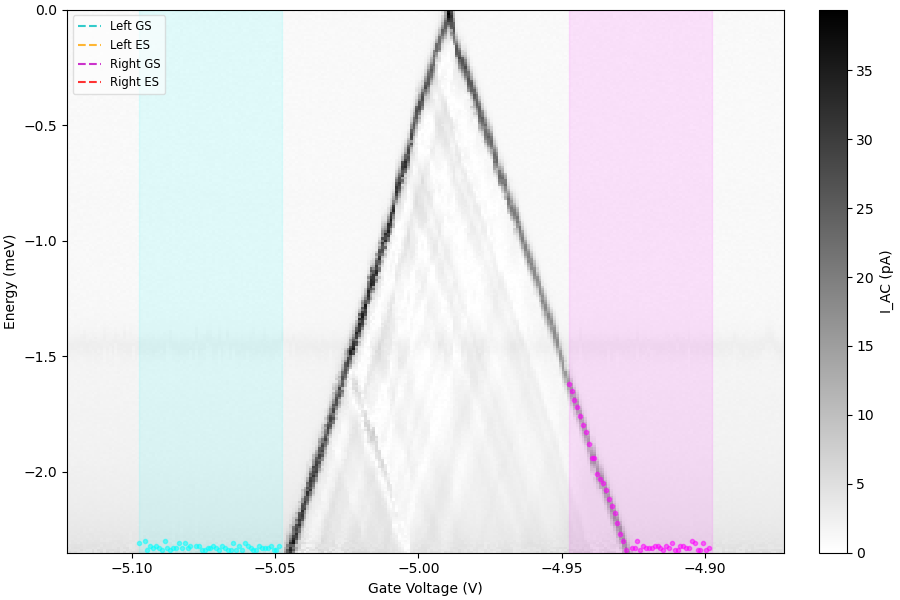

In [7]:
# --- EXECUTION ---
name='B0451  6VBG 1h diamond lever arm'
file_path='Z:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/04/Data_0427/%s.hdf5'%name
analysis = DiamondAnalysis(file_path)
create_dashboard(analysis)